# Customer Churn Prediction & Retention Analytics
### Objectives
- Understand customer churn patterns
- Clean and prepare the customer data
- Create useful customer-level features
- Perform exploratory data analysis
- Compare classification models
- Identify important churn factors
- Segment customers by predicted churn risk
- Recommend practical retention strategies


## 1. Import libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

os.makedirs("../plots", exist_ok=True)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Load the dataset



In [52]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx", sheet_name="Telco_Churn")

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Initial data inspection

In [53]:
print("Rows and columns:", df.shape)


Rows and columns: (7043, 33)


In [54]:
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [55]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [56]:
df.describe()


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [57]:
df.isnull().sum()


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [58]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [59]:
print("Churn distribution:")
print(df["Churn Label"].value_counts())

print("\nChurn percentage:")
print((df["Churn Label"].value_counts(normalize=True) * 100).round(2))


Churn distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## 4. Data Cleaning



In [60]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

print("Missing Total Charges before filling:", df["Total Charges"].isnull().sum())

df["Total Charges"] = df["Total Charges"].fillna(0)

print("Missing Total Charges after filling:", df["Total Charges"].isnull().sum())


Missing Total Charges before filling: 11
Missing Total Charges after filling: 0


In [61]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)


Dataset shape after removing duplicates: (7043, 33)


## 5. Feature Engineering

Three new features are created:

1 Average Monthly Spend
2 Tenure Group
3 Total Services

In [62]:
df["avg_monthly_spend"] = df["Total Charges"] / df["Tenure Months"].replace(0, np.nan)
df["avg_monthly_spend"] = df["avg_monthly_spend"].fillna(df["Monthly Charges"])

df["tenure_group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["new", "short", "medium", "long"]
)

df["total_services"] = (
    (df["Phone Service"] == "Yes").astype(int) +
    (df["Internet Service"] != "No").astype(int) +
    (df["Online Security"] == "Yes").astype(int) +
    (df["Online Backup"] == "Yes").astype(int) +
    (df["Device Protection"] == "Yes").astype(int) +
    (df["Tech Support"] == "Yes").astype(int) +
    (df["Streaming TV"] == "Yes").astype(int) +
    (df["Streaming Movies"] == "Yes").astype(int)
)

df[[
    "Tenure Months",
    "Total Charges",
    "avg_monthly_spend",
    "tenure_group",
    "total_services"
]].head()


,Tenure Months,Total Charges,avg_monthly_spend,tenure_group,total_services
0,2,108.15,54.075000,new,4
1,2,151.65,75.825000,new,2
2,8,820.50,102.562500,new,5
3,28,3046.05,108.787500,medium,6
4,49,5036.30,102.781633,long,6


In [63]:
print("Average monthly spend by churn:")
print(df.groupby("Churn Label")["avg_monthly_spend"].mean().round(2))

print("\nAverage number of services by churn:")
print(df.groupby("Churn Label")["total_services"].mean().round(2))


Average monthly spend by churn:
Churn Label
No     61.27
Yes    74.43
Name: avg_monthly_spend, dtype: float64

Average number of services by churn:
Churn Label
No     3.76
Yes    3.62
Name: total_services, dtype: float64


## 6. Exploratory Data Analysis

### 6.1 Churn distribution

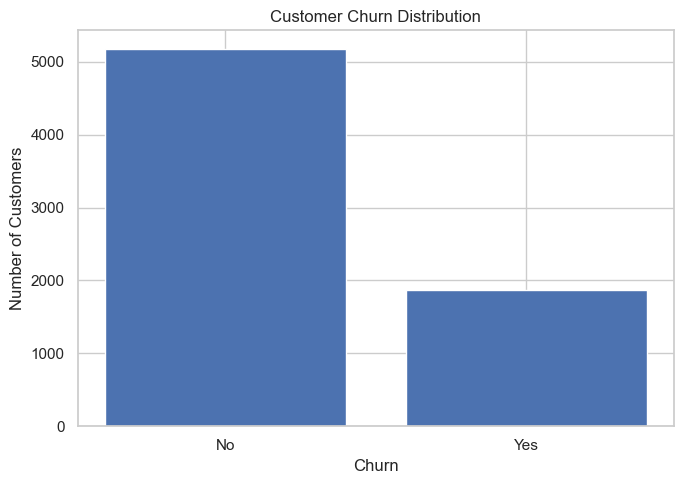

In [64]:
counts = df["Churn Label"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../plots/churn_distribution.png", dpi=300)
plt.show()


### 6.2 Customer tenure analysis

In [65]:
tenure_churn = df.groupby("tenure_group", observed=False)["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(tenure_churn.round(2))


tenure_group
new       47.44
short     28.71
medium    20.39
long       9.51
Name: Churn Label, dtype: float64


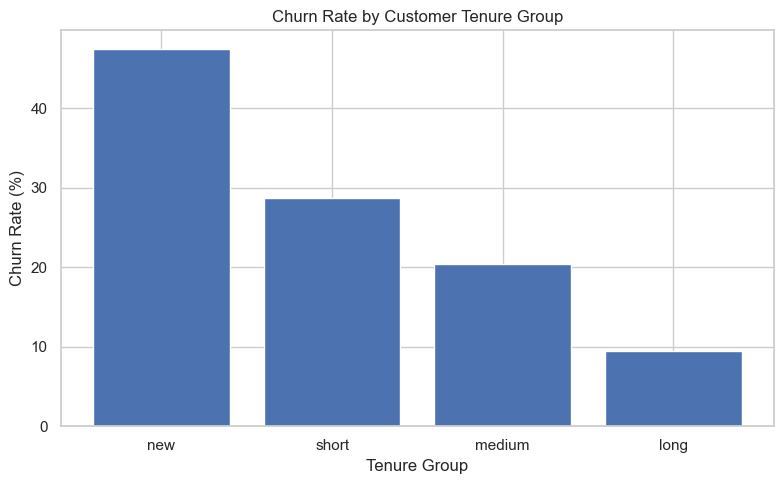

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(tenure_churn.index.astype(str), tenure_churn.values)
plt.title("Churn Rate by Customer Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("../plots/tenure_analysis.png", dpi=300)
plt.show()


### 6.3 Monthly charges distribution

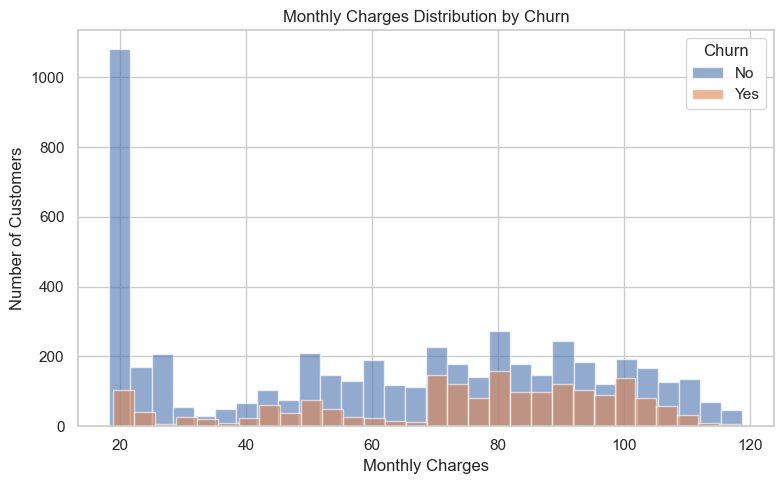

In [67]:
plt.figure(figsize=(8, 5))

for label in ["No", "Yes"]:
    values = df.loc[df["Churn Label"] == label, "Monthly Charges"]
    plt.hist(values, bins=30, alpha=0.6, label=label)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("../plots/monthly_charges.png", dpi=300)
plt.show()


In [68]:
print(df.groupby("Churn Label")["Monthly Charges"].mean().round(2))


Churn Label
No     61.27
Yes    74.44
Name: Monthly Charges, dtype: float64


### 6.4 Contract type comparison

In [69]:
contract_churn = df.groupby("Contract")["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)

print(contract_churn.round(2))


Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn Label, dtype: float64


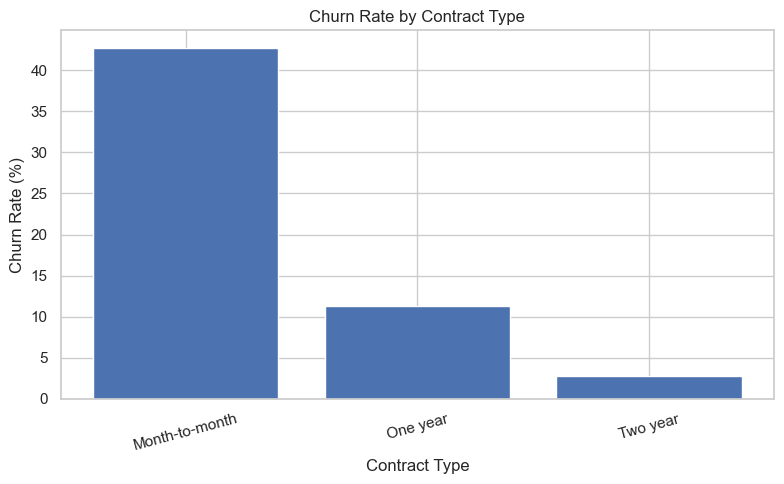

In [70]:
plt.figure(figsize=(8, 5))
plt.bar(contract_churn.index.astype(str), contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../plots/contract_churn.png", dpi=300)
plt.show()


### 6.5 Service usage analysis

In [71]:
service_churn = df.groupby("Internet Service")["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)

print("Churn rate by internet service:")
print(service_churn.round(2))


Churn rate by internet service:
Internet Service
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn Label, dtype: float64


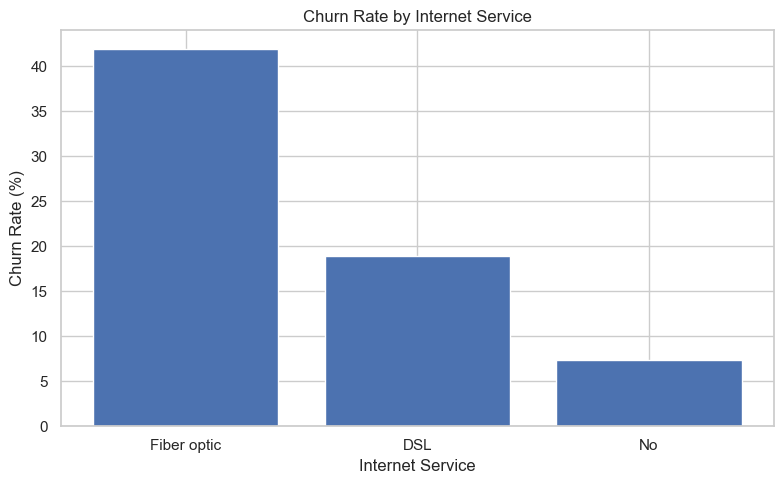

In [72]:
plt.figure(figsize=(8, 5))
plt.bar(service_churn.index.astype(str), service_churn.values)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("../plots/service_usage.png", dpi=300)
plt.show()


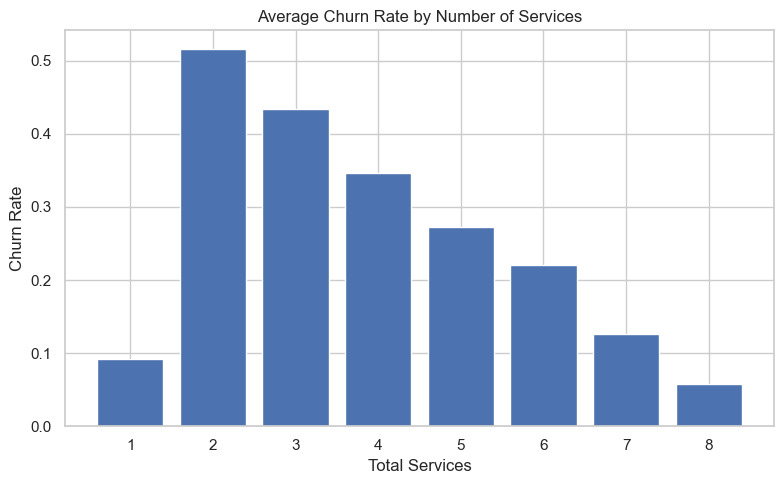

In [73]:
service_rate = df.groupby("total_services")["Churn Label"].apply(
    lambda x: (x == "Yes").mean()
)

plt.figure(figsize=(8, 5))
plt.bar(service_rate.index.astype(str), service_rate.values)
plt.title("Average Churn Rate by Number of Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()


### 6.6 Correlation heatmap

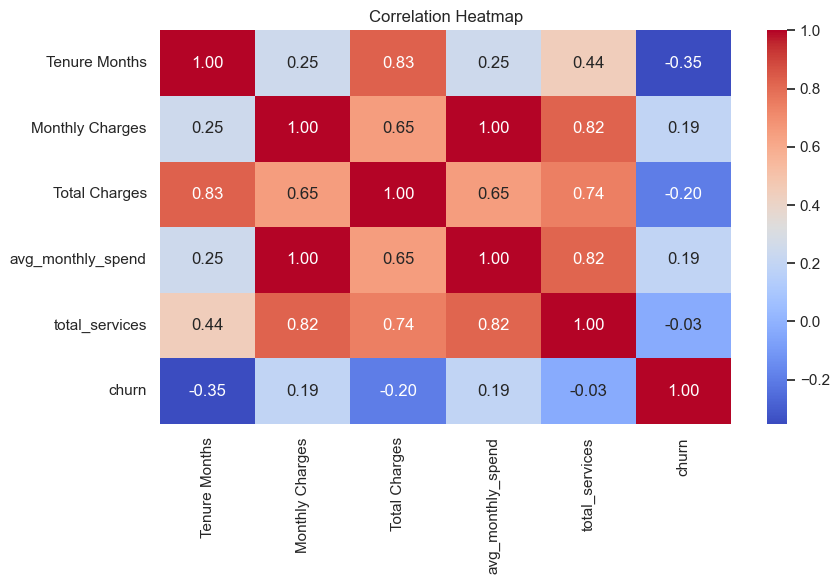

In [74]:
corr_df = df[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "avg_monthly_spend",
    "total_services"
]].copy()

corr_df["churn"] = (df["Churn Label"] == "Yes").astype(int)

plt.figure(figsize=(9, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../plots/correlation_heatmap.png", dpi=300)
plt.show()


## 7. Key EDA Findings

1. Month-to-month customers show a much higher churn rate compared to customers on one-year and two-year contracts.

2. Customers with low tenure are more likely to churn, while customers who have stayed longer tend to be more stable.

3. The average monthly charges are higher for customers who churn compared to those who stay.

4. Fiber optic customers have a higher churn rate compared to DSL customers and customers without internet service.

5. Customers using electronic checks have a higher churn rate than those using automatic bank transfer, automatic credit card, or mailed checks.

6. Tenure and churn show a negative relationship. In general, customers who have been with the company longer are less likely to churn.

## 8. Prepare Data for Machine Learning

The following columns were not used for model training:

- `CustomerID` and `Count`: these columns are not useful for predicting churn.
- Location columns: these were removed since location was not the focus of this analysis.
- `Churn Value`, `Churn Score`, and `Churn Reason`: these are related to the churn result, so using them could cause data leakage.
- `CLTV`: removed because it is already a calculated business score and the model should mainly learn from customer behavior.
- `Churn Label`: this is the target column, so it was used separately for prediction.

In [75]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason",
    "Churn Label"
]

x = df.drop(columns=drop_cols)
y = df["Churn Label"].map({"No": 0, "Yes": 1})

print("Number of features:", x.shape[1])
print(y.value_counts())


Number of features: 22
Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [76]:
cat_cols = x.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)


Categorical columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'tenure_group']

Numerical columns:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'avg_monthly_spend', 'total_services']


### Train-Test Split

In [77]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", x_train.shape)
print("Testing set:", x_test.shape)


Training set: (5634, 22)
Testing set: (1409, 22)


### Outlier Treatment

The IQR method is used to identify outliers 

In [78]:
for col in num_cols:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    x_train[col] = x_train[col].clip(lower, upper)
    x_test[col] = x_test[col].clip(lower, upper)

print("Outlier treatment completed.")


Outlier treatment completed.


### Encoding and Scaling

Numerical features are standardized. Categorical features are imputed and one-hot encoded.


In [79]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])


## 9. Machine Learning Models

In [80]:
models = {
    "logistic regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "decision tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),

    "random forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "xgboost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=4
    )
}


In [81]:
results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("pre", pre),
        ("model", model)
    ])

    pipe.fit(x_train, y_train)

    pred = pipe.predict(x_test)
    prob = pipe.predict_proba(x_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

    fitted_models[name] = pipe

results_df = pd.DataFrame(
    results,
    columns=["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
)

results_df.sort_values("f1", ascending=False)


,model,accuracy,precision,recall,f1,roc_auc
2,random forest,0.767921,0.544933,0.762032,0.635452,0.853170
0,logistic regression,0.748758,0.517544,0.788770,0.625000,0.849100
1,decision tree,0.739532,0.505983,0.791444,0.617310,0.841117
3,xgboost,0.808375,0.667742,0.553476,0.605263,0.856205


## 10. Hyperparameter Tuning

Random Forest and XGBoost are tuned using a small grid search. F1-score is used because it balances precision and recall.

In [82]:
rf_pipe = Pipeline([
    ("pre", pre),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [6, 10],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)


Best Random Forest parameters:
{'model__max_depth': 6, 'model__min_samples_split': 2, 'model__n_estimators': 250}


In [83]:
xgb_pipe = Pipeline([
    ("pre", pre),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=4
    ))
])

xgb_params = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(x_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)


Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 150, 'model__subsample': 0.8}


In [84]:
fitted_models["tuned random forest"] = rf_grid.best_estimator_
fitted_models["tuned xgboost"] = xgb_grid.best_estimator_

for name in ["tuned random forest", "tuned xgboost"]:
    model = fitted_models[name]
    pred = model.predict(x_test)
    prob = model.predict_proba(x_test)[:, 1]

    new_row = pd.DataFrame([{
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob)
    }])

    results_df = pd.concat([results_df, new_row], ignore_index=True)

results_df = results_df.drop_duplicates(subset="model")
results_df.sort_values(["f1", "roc_auc"], ascending=False)


,model,accuracy,precision,recall,f1,roc_auc
4,tuned random forest,0.758694,0.530249,0.796791,0.636752,0.851970
2,random forest,0.767921,0.544933,0.762032,0.635452,0.853170
0,logistic regression,0.748758,0.517544,0.788770,0.625000,0.849100
1,decision tree,0.739532,0.505983,0.791444,0.617310,0.841117
3,xgboost,0.808375,0.667742,0.553476,0.605263,0.856205
5,tuned xgboost,0.801987,0.653722,0.540107,0.591508,0.855525


## 11. Model Comparison

F1-score is the primary selection metric because it balances precision and recall.

ROC-AUC is used as a secondary metric because it measures how well the model separates churners from non-churners across different thresholds.


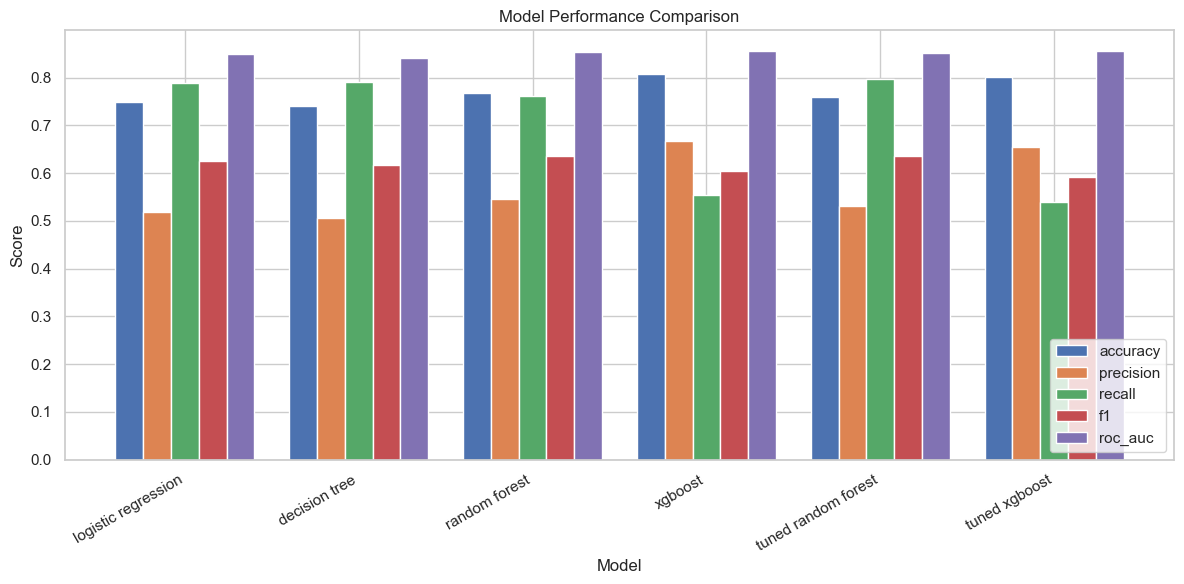

In [85]:
model_plot = results_df.set_index("model")[[
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]]

plt.figure(figsize=(12, 6))

x_pos = np.arange(len(model_plot.index))
width = 0.16

for i, col in enumerate(model_plot.columns):
    plt.bar(
        x_pos + i * width,
        model_plot[col].values,
        width=width,
        label=col
    )

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(
    x_pos + width * 2,
    model_plot.index,
    rotation=30,
    ha="right"
)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../plots/model_comparison.png", dpi=300)
plt.show()


In [86]:
best_row = results_df.sort_values(
    ["f1", "roc_auc"],
    ascending=False
).iloc[0]

best_name = best_row["model"]
best_model = fitted_models[best_name]

print("Best model:", best_name)
print()
print(best_row)


Best model: tuned random forest

model        tuned random forest
accuracy                0.758694
precision               0.530249
recall                  0.796791
f1                      0.636752
roc_auc                  0.85197
Name: 4, dtype: object


## 12. Confusion Matrix and Classification Report

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



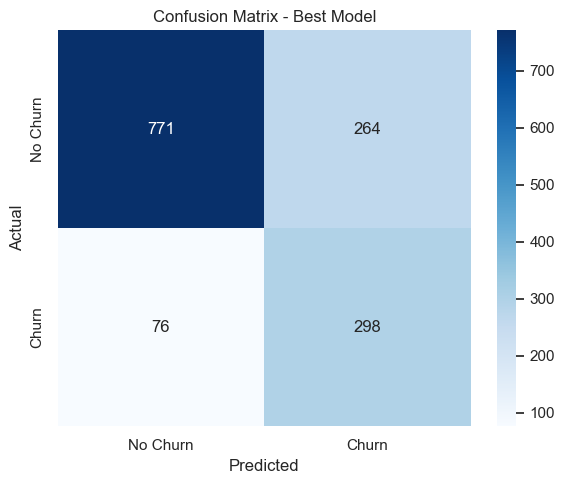

In [87]:
best_pred = best_model.predict(x_test)

print(classification_report(
    y_test,
    best_pred,
    target_names=["No Churn", "Churn"]
))

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../plots/confusion_matrix.png", dpi=300)
plt.show()


## 13. Feature Importance

For a tree-based best model, feature importance shows which transformed features contribute most to the model's decisions.


In [88]:
if best_name in [
    "random forest",
    "tuned random forest",
    "xgboost",
    "tuned xgboost"
]:
    tree_model = best_model.named_steps["model"]
    feature_names = best_model.named_steps["pre"].get_feature_names_out()

    importance = pd.Series(
        tree_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    print(importance.head(15))
else:
    print("The selected model does not have built-in tree feature importance.")


cat__Contract_Month-to-month            0.144352
num__Tenure Months                      0.093221
cat__Contract_Two year                  0.064092
cat__Tech Support_No                    0.062057
cat__Online Security_No                 0.060670
cat__Internet Service_Fiber optic       0.057714
cat__Dependents_No                      0.051687
num__Total Charges                      0.051362
cat__Dependents_Yes                     0.049671
cat__tenure_group_new                   0.048988
cat__Payment Method_Electronic check    0.035859
num__Monthly Charges                    0.034358
num__avg_monthly_spend                  0.031066
cat__tenure_group_long                  0.020445
cat__Contract_One year                  0.017754
dtype: float64


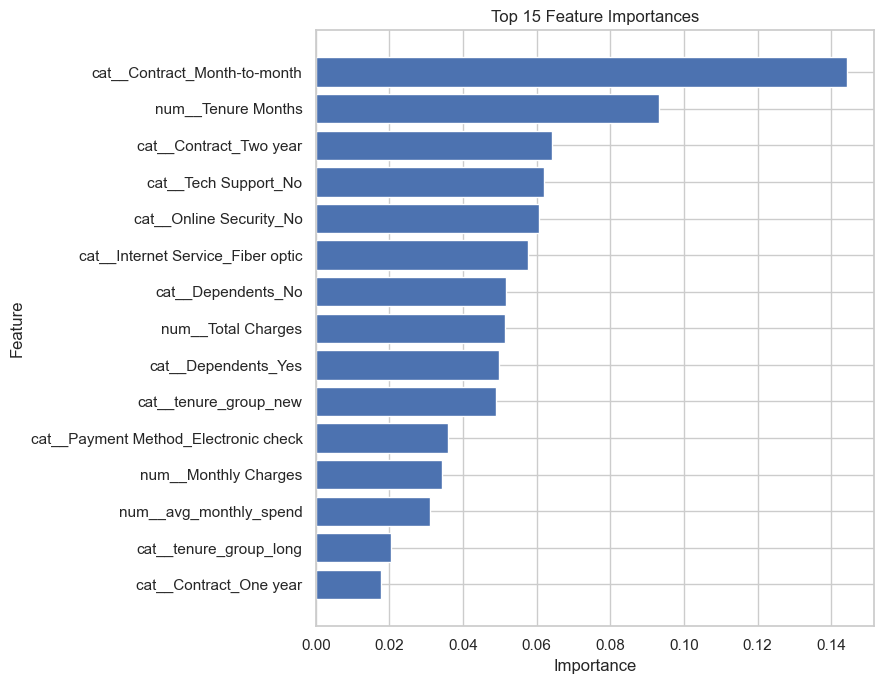

In [89]:
if best_name in [
    "random forest",
    "tuned random forest",
    "xgboost",
    "tuned xgboost"
]:
    top_importance = importance.head(15).sort_values()

    plt.figure(figsize=(9, 7))
    plt.barh(top_importance.index, top_importance.values)
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("../plots/feature_importance.png", dpi=300)
    plt.show()


## 14. SHAP Explanation

SHAP is used to explain the predictions of the selected tree-based model. A sample of the test set is used so that the plot remains readable.


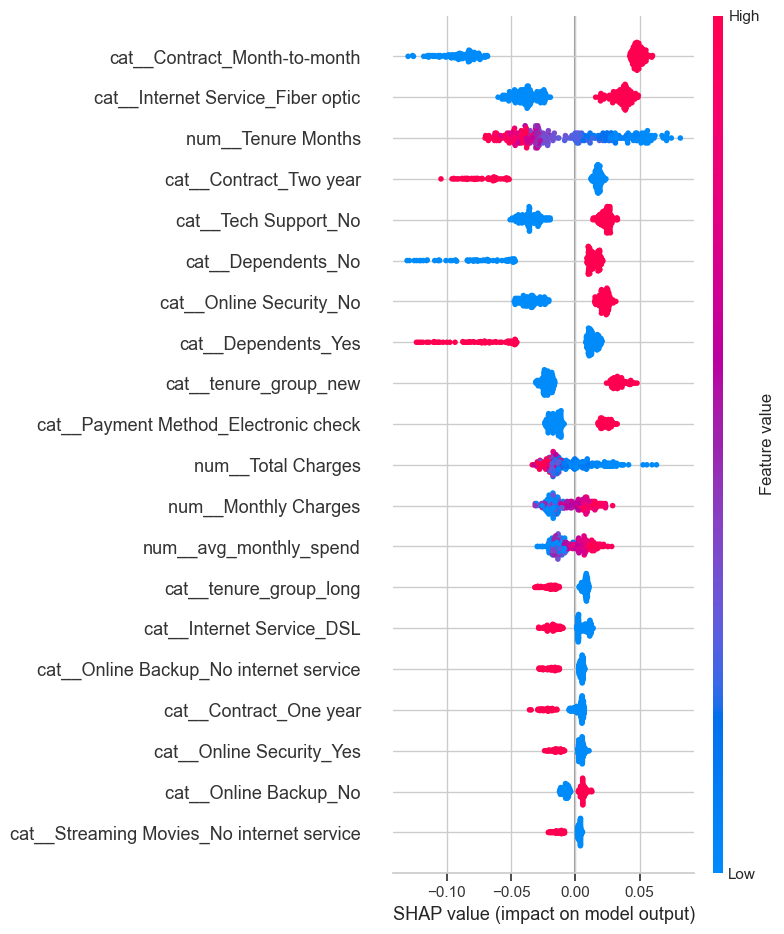

In [90]:
if best_name in [
    "random forest",
    "tuned random forest",
    "xgboost",
    "tuned xgboost"
]:
    shap_model = best_model.named_steps["model"]
    shap_x = best_model.named_steps["pre"].transform(x_test)
    shap_x = shap_x[:300]

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(shap_x)

    if isinstance(shap_values, list):
        shap_plot_values = shap_values[1]
    elif np.array(shap_values).ndim == 3:
        shap_plot_values = shap_values[:, :, 1]
    else:
        shap_plot_values = shap_values

    shap.summary_plot(
        shap_plot_values,
        shap_x,
        feature_names=feature_names,
        show=False
    )

    plt.tight_layout()
    plt.savefig(
        "../plots/shap_summary.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("SHAP tree explanation is not available for the selected model.")


## 15. Customer Churn Risk Segmentation

Churn probability is calculated for every customer.

Risk groups-
- High risk= probability >= 70%
- Medium risk= probability between 40% and 70%
- Low risk= probability < 40%

These thresholds are practical starting points and can be changed depending on the company's retention budget.


In [91]:
all_x = x.copy()

for col in num_cols:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    all_x[col] = all_x[col].clip(lower, upper)

all_prob = best_model.predict_proba(all_x)[:, 1]

risk_df = df[[
    "CustomerID",
    "Tenure Months",
    "Contract",
    "Internet Service",
    "Monthly Charges",
    "Total Charges",
    "Churn Label"
]].copy()

risk_df["churn_probability"] = all_prob

risk_df["risk_group"] = pd.cut(
    risk_df["churn_probability"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=["low", "medium", "high"]
)

risk_df.head()


,CustomerID,Tenure Months,Contract,Internet Service,Monthly Charges,Total Charges,Churn Label,churn_probability,risk_group
0,3668-QPYBK,2,Month-to-month,DSL,53.85,108.15,Yes,0.604774,medium
1,9237-HQITU,2,Month-to-month,Fiber optic,70.70,151.65,Yes,0.727395,high
2,9305-CDSKC,8,Month-to-month,Fiber optic,99.65,820.50,Yes,0.696640,medium
3,7892-POOKP,28,Month-to-month,Fiber optic,104.80,3046.05,Yes,0.403735,medium
4,0280-XJGEX,49,Month-to-month,Fiber optic,103.70,5036.30,Yes,0.355242,low


In [92]:
risk_summary = risk_df["risk_group"].value_counts().reindex(
    ["high", "medium", "low"]
)

print("Customers by risk group:")
print(risk_summary)


Customers by risk group:
risk_group
high      1557
medium    1845
low       3641
Name: count, dtype: int64


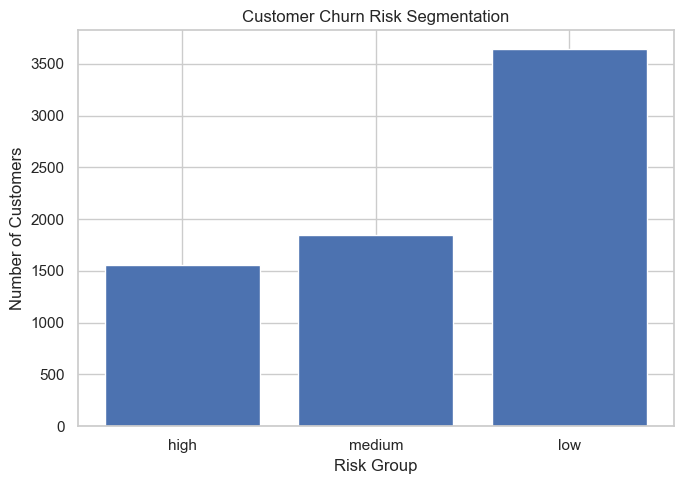

In [93]:
plt.figure(figsize=(7, 5))
plt.bar(
    risk_summary.index.astype(str),
    risk_summary.values
)
plt.title("Customer Churn Risk Segmentation")
plt.xlabel("Risk Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../plots/risk_segmentation.png", dpi=300)
plt.show()


## 16. High-Risk Customer Analysis

In [94]:
high_risk = risk_df[risk_df["risk_group"] == "high"].copy()

print("Number of high-risk customers:", len(high_risk))

print("\nHigh-risk customers by contract:")
print(high_risk["Contract"].value_counts())

print("\nAverage monthly charges of high-risk customers:")
print(round(high_risk["Monthly Charges"].mean(), 2))

print("\nAverage tenure of high-risk customers:")
print(round(high_risk["Tenure Months"].mean(), 2))


Number of high-risk customers: 1557

High-risk customers by contract:
Contract
Month-to-month    1557
Name: count, dtype: int64

Average monthly charges of high-risk customers:
78.59

Average tenure of high-risk customers:
10.43


In [95]:
risk_by_contract = pd.crosstab(
    risk_df["Contract"],
    risk_df["risk_group"],
    normalize="index"
) * 100

risk_by_contract.round(2)


risk_group,low,medium,high
Contract,,,
Month-to-month,20.23,39.59,40.18
One year,79.57,20.43,0.00
Two year,99.41,0.59,0.00


## 17. Business Recommendations

### 1. Focus on month-to-month customers

Month-to-month customers have a much higher churn rate. Offer suitable discounts or extra benefits to encourage them to move to longer-term contracts.

### 2. Target new customers early

New customers are more likely to churn. Better onboarding, regular check-ins, and early support can help improve retention during the first year.

### 3. Review customers with high monthly charges

Customers with higher monthly charges are more likely to churn. Personalized plans or targeted discounts can be used for customers who are sensitive to pricing.

### 4. Improve the fiber optic customer experience

Fiber optic customers show higher churn in this dataset. It would be useful to check service quality, pricing, technical issues, and support for these customers.

### 5. Reduce electronic-check related churn

Customers using electronic checks have a higher churn rate. The company can encourage automatic bank transfer or credit-card payments by offering small incentives.

### 6. Prioritize high-risk customers

Use the predicted churn probability to identify customers who need more attention. This helps focus retention efforts instead of treating every customer the same way.

### 7. Consider customer value along with churn risk

High-risk customers who are also valuable to the business can be given more personalized retention offers and support.

### 8. Use churn predictions before customers leave

The model can be used to identify risky customers early and trigger actions such as support calls, targeted offers, or loyalty benefits before they decide to leave.

## 18. Conclusion

In this project, customer data was used to understand and predict customer churn. The analysis looked at customer details, services, contracts, tenure, monthly charges, and payment methods.

The EDA showed some clear patterns in churn. Month-to-month contracts, low tenure, higher monthly charges, fiber optic service, and electronic check payments were some of the important factors related to churn.

Different machine learning models were tested and compared using accuracy, precision, recall, F1-score, and ROC-AUC. The Tuned Random Forest was selected as the final model because it gave the best F1-score and recall among the final models.

The model was also used to divide customers into low-, medium-, and high-risk groups. These groups can help the business decide which customers should be given more attention.

Overall, the project shows how customer data and machine learning can be used to identify churn risk and support better retention decisions.

## 19. Final Checklist

- Data loading and inspection
- Missing-value analysis
- Duplicate check
- Data cleaning
- Feature engineering
- Outlier treatment
- Churn distribution
- Tenure analysis
- Monthly charges analysis
- Contract comparison
- Service usage analysis
- Correlation heatmap
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Hyperparameter tuning
- Accuracy, Precision, Recall, F1, ROC-AUC
- Confusion matrix
- Feature importance
- SHAP explanation
- Customer risk segmentation
- Business recommendations